<a href="https://colab.research.google.com/github/selvamaran/a26cnW2D2_timeseries/blob/main/Sampling_frequency_Aliasing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

In [2]:
# Parameters
fs_original = 1000  # Original sampling frequency (Hz), high enough to capture true signal
t_original = np.arange(0, 1, 1/fs_original) # Time vector for original signal (1 second duration)

f_signal = 150      # True frequency of the signal (Hz)
signal_original = np.sin(2 * np.pi * f_signal * t_original)

# Undersampling parameters
fs_sampled = 70     # Low sampling frequency (Hz) - less than 2 * f_signal, causing aliasing
t_sampled = np.arange(0, 1, 1/fs_sampled) # Time vector for sampled signal
signal_sampled = np.sin(2 * np.pi * f_signal * t_sampled)

In [3]:
# Calculate perceived frequency of the aliased signal
# The perceived frequency (f_aliased) can be calculated as |f_signal - n * fs_sampled|
# where n is an integer such that f_aliased is minimized and within [0, fs_sampled/2]

f_aliased = np.abs(f_signal - np.round(f_signal / fs_sampled) * fs_sampled)

print(f"\nOriginal signal frequency: {f_signal} Hz")
print(f"Sampling frequency: {fs_sampled} Hz")
print(f"Perceived (aliased) frequency: {f_aliased} Hz")


Original signal frequency: 150 Hz
Sampling frequency: 70 Hz
Perceived (aliased) frequency: 10.0 Hz


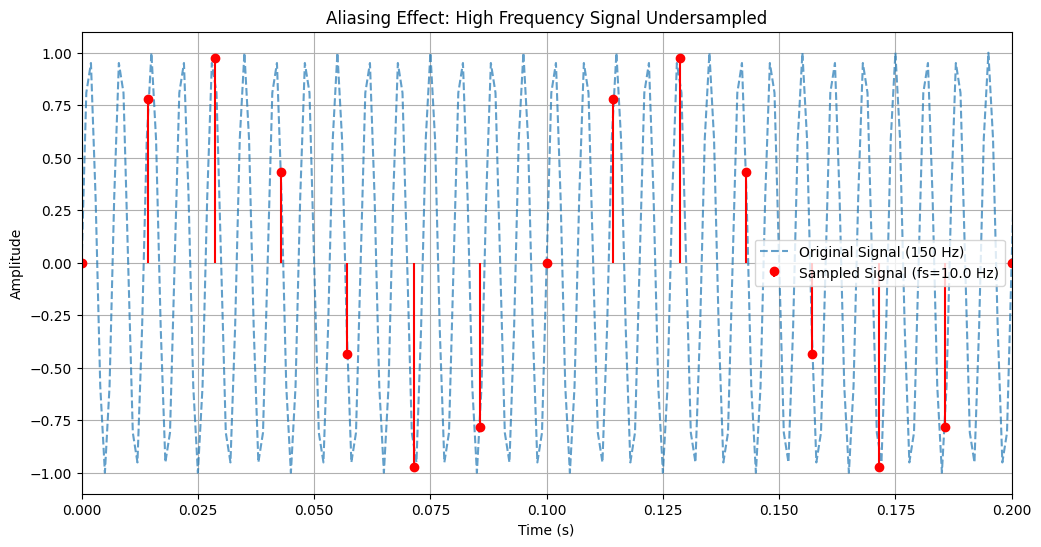

In [4]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(t_original, signal_original, label=f'Original Signal ({f_signal} Hz)', alpha=0.7, linestyle='--')
plt.stem(t_sampled, signal_sampled, linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Sampled Signal (fs={f_aliased} Hz)')
plt.title('Aliasing Effect: High Frequency Signal Undersampled')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.2) # Zoom in to see the effect more clearly
plt.show()

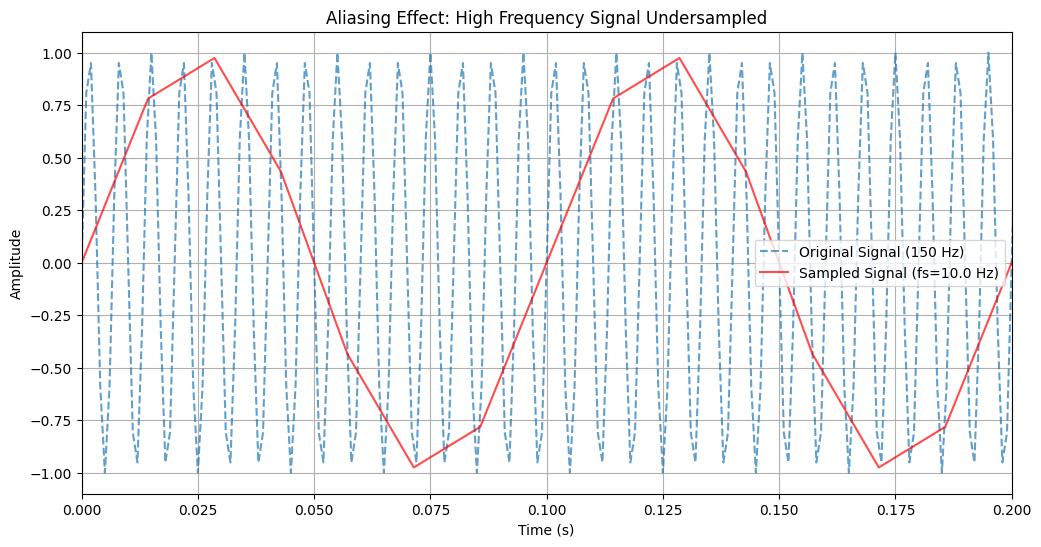

In [5]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(t_original, signal_original, label=f'Original Signal ({f_signal} Hz)', alpha=0.7, linestyle='--')
plt.plot(t_sampled, signal_sampled, color='r', label=f'Sampled Signal (fs={f_aliased} Hz)', alpha=0.7)
plt.title('Aliasing Effect: High Frequency Signal Undersampled')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.2) # Zoom in to see the effect more clearly
plt.show()

In [10]:
import ipywidgets as widgets
from IPython.display import display

def plot_aliasing(plot_type='smooth'):
    plt.figure(figsize=(12, 6))
    plt.plot(t_original, signal_original, label=f'Original Signal ({f_signal} Hz)', alpha=0.7, linestyle='--')

    if plot_type == 'stem':
        plt.stem(t_sampled, signal_sampled, linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Sampled Signal (fs={f_aliased} Hz)')
    else: # Default to smooth plot
        plt.plot(t_sampled, signal_sampled, color='r', label=f'Sampled Signal (fs={f_aliased} Hz)', alpha=0.7)

    plt.title('Aliasing Effect: High Frequency Signal Undersampled')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 0.2) # Zoom in to see the effect more clearly
    plt.show()

plot_type_selector = widgets.Dropdown(
    options=['smooth', 'stem'],
    value='stem',
    description='Sampled Plot Type:',
    disabled=False,
)

widgets.interactive(plot_aliasing, plot_type=plot_type_selector)

interactive(children=(Dropdown(description='Sampled Plot Type:', index=1, options=('smooth', 'stem'), value='s…

Text(0, 0.5, 'Amplitude')

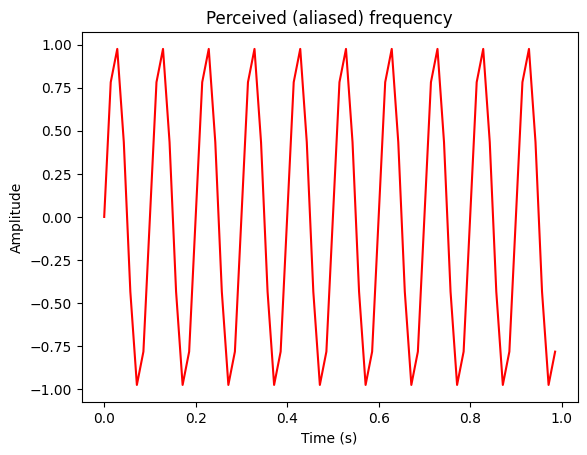

In [6]:
plt.plot(t_sampled, signal_sampled, color='red')
plt.title('Perceived (aliased) frequency')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
# plt.grid(True)

### Optional

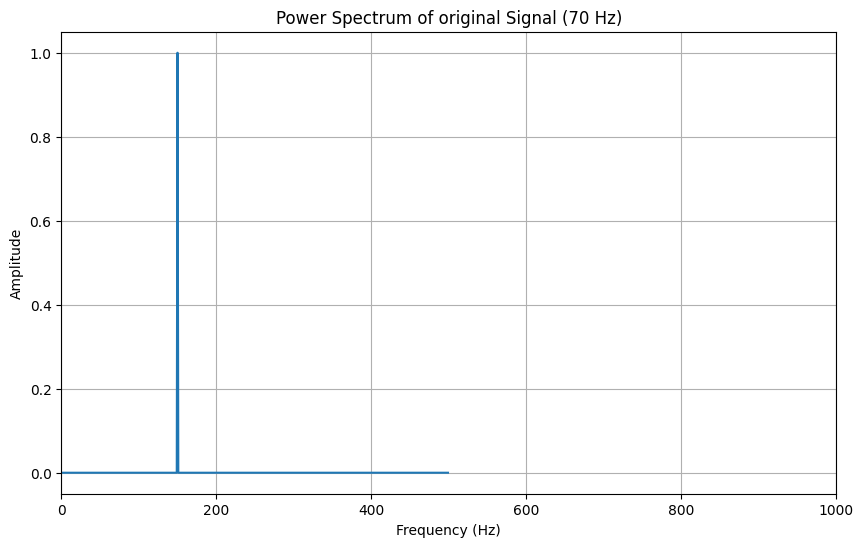

In [7]:
# Calculate the Fourier Transform
N = len(signal_original) # Number of sample points
T = 1.0 / fs_original # Sample spacing

yf = fft(signal_original)
x = fftfreq(N, T)[:N//2]

# Plotting the power spectrum
plt.figure(figsize=(10, 6))
plt.plot(x, 2.0/N * np.abs(yf[0:N//2]))
plt.title('Power Spectrum of original Signal (70 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0,fs_original)
plt.show()

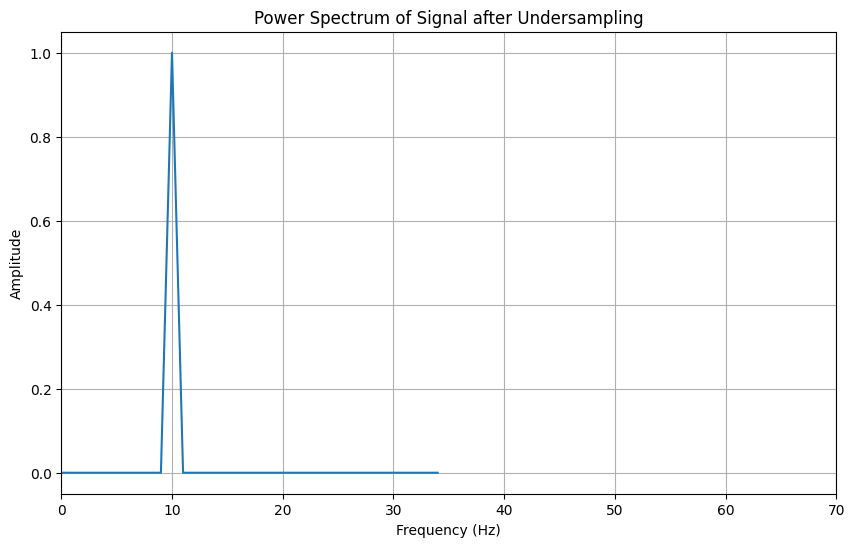

In [8]:
# Calculate the Fourier Transform
N = len(signal_sampled) # Number of sample points
T = 1.0 / fs_sampled # Sample spacing

yf = fft(signal_sampled)
x = fftfreq(N, T)[:N//2]

# Plotting the power spectrum
plt.figure(figsize=(10, 6))
plt.plot(x, 2.0/N * np.abs(yf[0:N//2]))
plt.title('Power Spectrum of Signal after Undersampling')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0,fs_sampled)
plt.show()